In [46]:
import numpy as np
import pandas as pd 
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
#Setting up the dataset path and listing files in dataset folder
dataset_path = "./titanic 2"
print(os.listdir(dataset_path))

['test.csv', 'train.csv', 'gender_submission.csv']


Lets start analysing the data files

In [48]:
gender_submission = pd.read_csv('./titanic 2/gender_submission.csv')
gender_submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [49]:
train = pd.read_csv('./titanic 2/train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [50]:
test = pd.read_csv('./titanic 2/test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


As can be seen, there are some missing values in the dataset. Lets see which columns have how many missing values.

In [51]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [52]:
train.dropna(inplace=True)
train.isnull().sum()
#Dropping the columns which has null values.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Now visualise the training dataset to understand what we got a bit better.

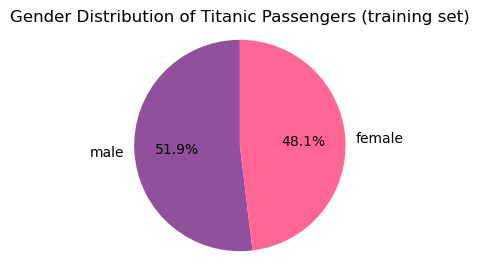

In [53]:
#Gender distribution of passengers in the training set
gender_count = train['Sex'].value_counts()

plt.figure(figsize=(3, 3))
colors = ["#91509b","#ff6694" ]

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Gender Distribution of Titanic Passengers (training set)')
plt.axis('equal')

plt.show()

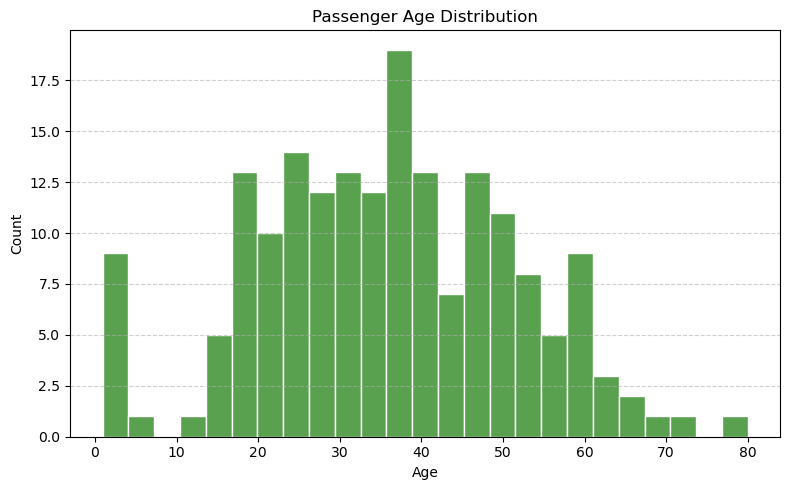

In [54]:
#Passanger Age distribution in the training set
plt.figure(figsize=(8, 5))

plt.hist(
    train['Age'].dropna(),
    bins=25,
    color='#59a14f',
    edgecolor='white'
)

plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

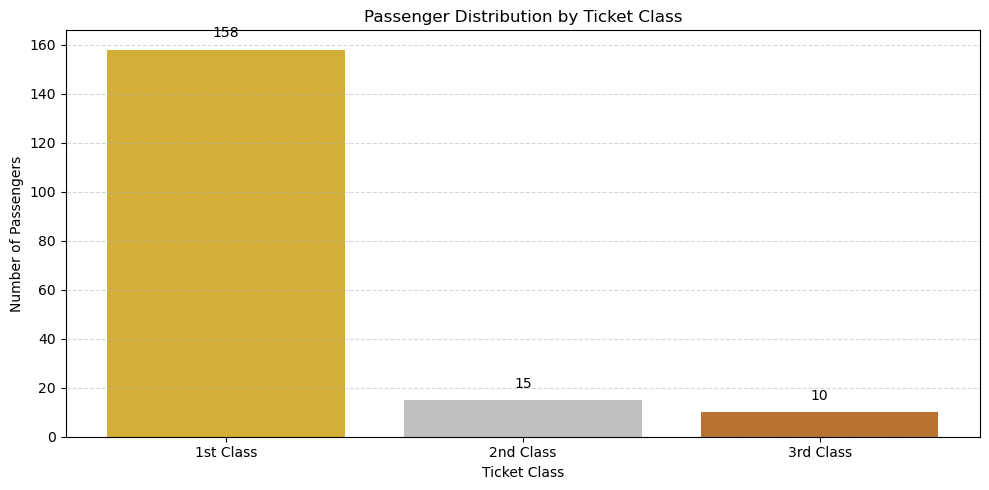

In [55]:
#Ticket class distribution of passengers in the training set
pclass_counts = train['Pclass'].value_counts().sort_index()
colors = ['#d4af37', '#c0c0c0', '#b87333']

plt.figure(figsize=(10, 5))

bars = plt.bar(
    pclass_counts.index,
    pclass_counts.values,
    color=colors
)

plt.title('Passenger Distribution by Ticket Class')
plt.xlabel('Ticket Class')
plt.ylabel('Number of Passengers')

plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height),
             ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

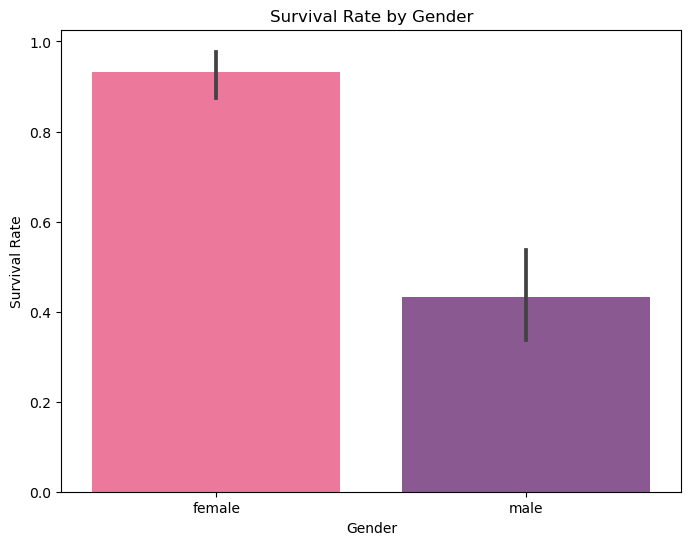

In [57]:
plt.figure(figsize=(8, 6))
colors = ["#ff6694", "#91509b"]
sns.barplot(x='Sex', y='Survived', data=train, palette=colors)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.xlabel('Gender')

plt.show()

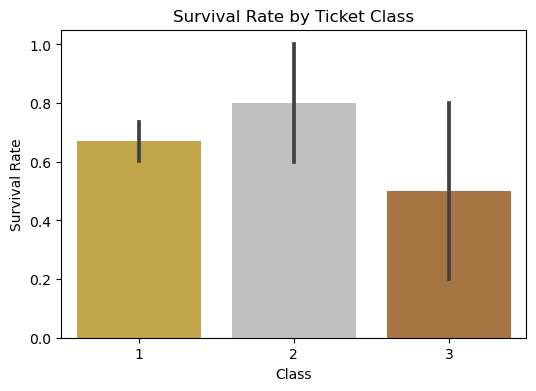

In [59]:
plt.figure(figsize=(6, 4))
colors = ['#d4af37', '#c0c0c0', '#b87333']
sns.barplot(x='Pclass', y='Survived', data=train, palette=colors)

plt.title('Survival Rate by Ticket Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')

plt.show()

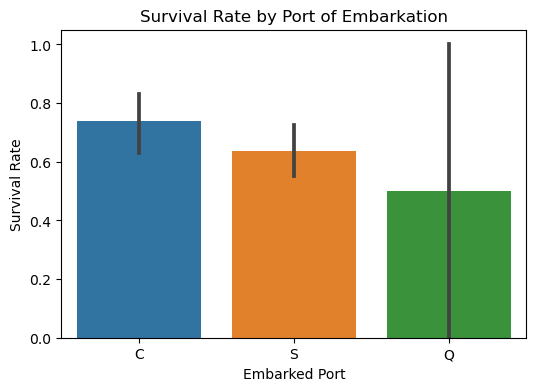

In [60]:
plt.figure(figsize=(6, 4))

sns.barplot(x='Embarked', y='Survived', data=train)

plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Embarked Port')
plt.ylabel('Survival Rate')

plt.show()

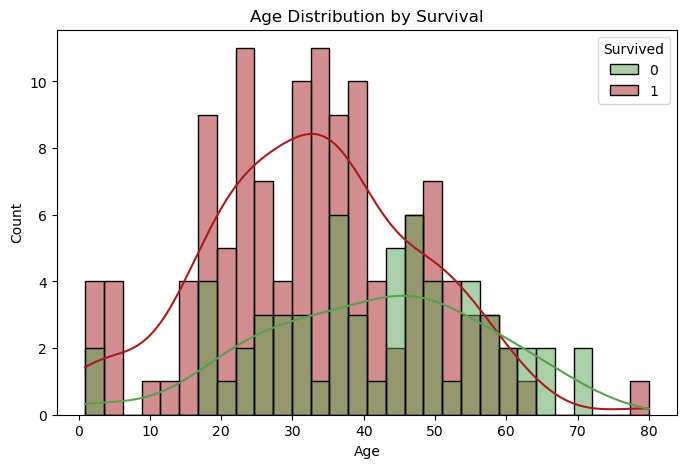

In [63]:
plt.figure(figsize=(8, 5))
colors = ['#59a14f', "#a71c1e"]
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True, palette=colors)

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()